<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px solid #0047AB;">

<h1 style="margin-bottom:0;"><b> Machine Learning II </b></h1>

<h3><b> Exploratory Data Analysis and Pre-Processing </b></h3>


<div style="background-color:#EFF5FF; padding:15px; border-radius:10px;">

**Table of Contents**



<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px solid #0047AB;">
<h3><b> 1 Imports and Data Loading </b></h3>

In [1]:
import numpy as np
import pandas as pd
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from pylab import rcParams
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
import warnings

import utils_eda as utils
warnings.filterwarnings("ignore")

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px solid #0047AB;">
<h3><b> 1.1 Data Analysis </b></h3>

In [3]:
ci = pd.read_csv("Data/customer_info.csv", index_col = 'customer_id')
print(f"Dataset shape: {ci.shape[0]:,} rows and {ci.shape[1]} columns")

Dataset shape: 33,038 rows and 24 columns


In [4]:
pd.set_option('display.max_columns', None)
ci.sort_index(inplace = True)
display(ci.head())

,customer_name,customer_gender,customer_birthdate,kids_home,teens_home,number_complaints,distinct_stores_visited,lifetime_spend_groceries,lifetime_spend_electronics,typical_hour,lifetime_spend_vegetables,lifetime_spend_nonalcohol_drinks,lifetime_spend_alcohol_drinks,lifetime_spend_meat,lifetime_spend_fish,lifetime_spend_hygiene,lifetime_spend_videogames,lifetime_spend_petfood,lifetime_total_distinct_products,percentage_of_products_bought_promotion,year_first_transaction,loyalty_card_number,latitude,longitude
customer_id,,,,,,,,,,,,,,,,,,,,,,,,
3,Bsc. Crystal Kitchens,female,02/12/1970 01:36 PM,1.0,1.0,1.0,3.0,11731.0,4553.0,NaN,373.0,323.0,177.0,28.0,213.0,552.0,256.0,384.0,189.0,0.631599,2020.0,1.0,38.794428,-9.215739
4,Bsc. Glenda Bauman,female,11/13/1975 06:58 PM,1.0,0.0,0.0,2.0,13694.0,963.0,NaN,2012.0,533.0,95.0,43.0,15.0,1880.0,333.0,665.0,130.0,0.149890,2013.0,1.0,38.751711,-9.179611
5,Msc. Antonio Campbell,male,09/10/1971 10:07 AM,0.0,0.0,NaN,2.0,12407.0,0.0,11.0,555.0,101.0,118.0,1265.0,273.0,507.0,101.0,222.0,81.0,0.069126,2005.0,NaN,38.780678,-9.160656
7,John Kelling,male,10/23/1982 11:20 AM,0.0,0.0,2.0,1.0,7493.0,1105.0,18.0,84.0,757.0,1133.0,972.0,1083.0,485.0,1656.0,184.0,92.0,0.253609,2021.0,1.0,38.739548,-9.148679
8,Arthur Dematteo,male,08/04/1969 10:22 PM,0.0,0.0,3.0,1.0,9187.0,10841.0,17.0,380.0,592.0,718.0,1068.0,1015.0,297.0,1258.0,441.0,6.0,0.186569,2021.0,1.0,38.733071,-9.188188


In [5]:
display(ci.tail())

,customer_name,customer_gender,customer_birthdate,kids_home,teens_home,number_complaints,distinct_stores_visited,lifetime_spend_groceries,lifetime_spend_electronics,typical_hour,lifetime_spend_vegetables,lifetime_spend_nonalcohol_drinks,lifetime_spend_alcohol_drinks,lifetime_spend_meat,lifetime_spend_fish,lifetime_spend_hygiene,lifetime_spend_videogames,lifetime_spend_petfood,lifetime_total_distinct_products,percentage_of_products_bought_promotion,year_first_transaction,loyalty_card_number,latitude,longitude
customer_id,,,,,,,,,,,,,,,,,,,,,,,,
39996,Joshua Howard,male,05/16/1973 02:04 PM,0.0,0.0,2.0,1.0,475.0,13488.0,NaN,190.0,573.0,994.0,1020.0,1154.0,62.0,1598.0,366.0,162.0,0.261352,2014.0,NaN,38.742306,-9.163971
39997,Anthony Hines,male,05/10/1955 01:19 AM,1.0,0.0,1.0,1.0,8430.0,14408.0,21.0,291.0,497.0,1417.0,1323.0,602.0,220.0,2105.0,227.0,97.0,0.143479,2014.0,NaN,38.748505,-9.193445
39998,Edna Hasselman,female,05/15/1945 11:09 PM,1.0,1.0,0.0,4.0,8029.0,1480.0,14.0,1600.0,494.0,117.0,307.0,NaN,1719.0,89.0,258.0,206.0,0.181917,2012.0,NaN,38.776003,-9.137943
39999,George Kramer,male,05/25/1951 09:02 PM,1.0,1.0,1.0,6.0,8364.0,3114.0,11.0,596.0,303.0,661.0,NaN,113.0,410.0,NaN,225.0,385.0,0.807259,2017.0,NaN,38.736034,-9.145235
40000,Sammie Wright,female,07/09/1990 10:27 AM,0.0,1.0,1.0,1.0,4774.0,2127.0,7.0,701.0,387.0,126.0,816.0,729.0,1331.0,323.0,239.0,102.0,0.252563,2017.0,NaN,38.758936,-9.145988


In [6]:
display(ci.info(memory_usage="deep"))

<class 'pandas.core.frame.DataFrame'>
Index: 33038 entries, 3 to 40000
Data columns (total 24 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   customer_name                            33038 non-null  object 
 1   customer_gender                          33038 non-null  object 
 2   customer_birthdate                       32873 non-null  object 
 3   kids_home                                32708 non-null  float64
 4   teens_home                               32708 non-null  float64
 5   number_complaints                        32377 non-null  float64
 6   distinct_stores_visited                  32708 non-null  float64
 7   lifetime_spend_groceries                 33038 non-null  float64
 8   lifetime_spend_electronics               32377 non-null  float64
 9   typical_hour                             32377 non-null  float64
 10  lifetime_spend_vegetables                32377 non-

None

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px solid #0047AB;">
<h3><b> 1.2 Duplicate Rows Analysis </b></h3>

In [7]:
duplicate_rows = ci[ci.duplicated()]
display(duplicate_rows.head())

,customer_name,customer_gender,customer_birthdate,kids_home,teens_home,number_complaints,distinct_stores_visited,lifetime_spend_groceries,lifetime_spend_electronics,typical_hour,lifetime_spend_vegetables,lifetime_spend_nonalcohol_drinks,lifetime_spend_alcohol_drinks,lifetime_spend_meat,lifetime_spend_fish,lifetime_spend_hygiene,lifetime_spend_videogames,lifetime_spend_petfood,lifetime_total_distinct_products,percentage_of_products_bought_promotion,year_first_transaction,loyalty_card_number,latitude,longitude
customer_id,,,,,,,,,,,,,,,,,,,,,,,,


<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px solid #0047AB;">
<h3><b> 1.3 Missing Values Analysis </b></h3>

In [10]:
missing_df = utils.get_missing_percent(ci)

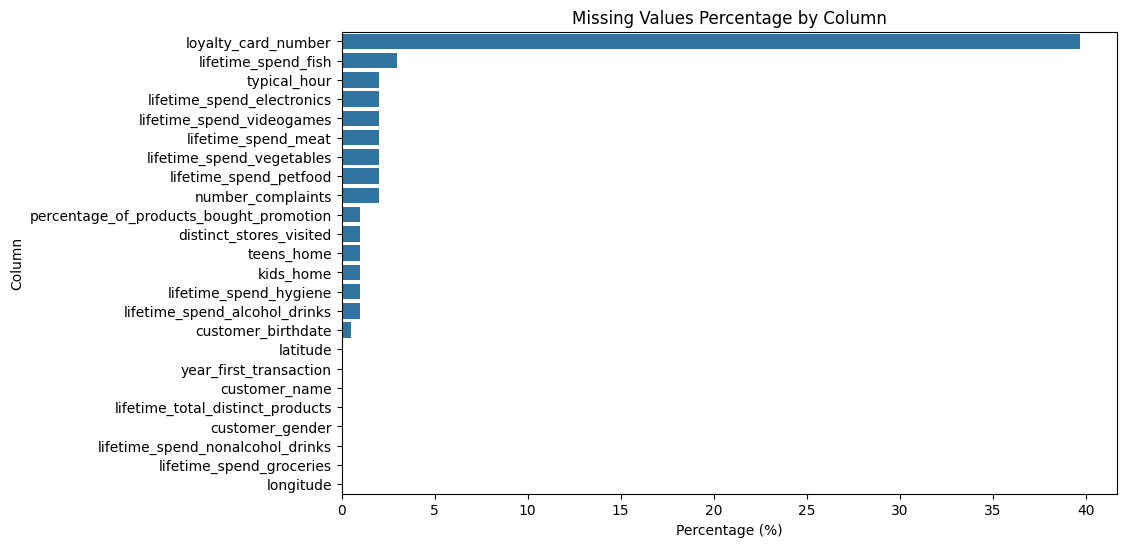

In [11]:
plt.figure(figsize=(10,6))
sns.barplot(x='Missing_Percent', y='Column', data=missing_df)
plt.title("Missing Values Percentage by Column")
plt.xlabel("Percentage (%)")
plt.ylabel("Column")
plt.show()

In [12]:
high_missing = missing_df[missing_df['Missing_Percent'] > 30]
display(high_missing)

,Column,Missing_Percent
21,loyalty_card_number,39.67


In [22]:
print(f"Unique Values of column loyalty_card_number: {ci['loyalty_card_number'].nunique()}")

Unique Values of column loyalty_card_number: 1


<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px solid #0047AB;">
<h3><b> 2.4 Define Numerical and Categorical Columns</b></h3>

In [13]:
numerical_cols = ci.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = ci.select_dtypes(include=['object', 'category']).columns.tolist()

print(f"Numerical columns ({len(numerical_cols)}):")
display(pd.DataFrame(numerical_cols, columns=['Numerical Columns']))

print(f"Categorical columns ({len(categorical_cols)}):")
display(pd.DataFrame(categorical_cols, columns=['Categorical Columns']))

Numerical columns (21):


,Numerical Columns
0,kids_home
1,teens_home
2,number_complaints
3,distinct_stores_visited
4,lifetime_spend_groceries
5,lifetime_spend_electronics
6,typical_hour
7,lifetime_spend_vegetables
8,lifetime_spend_nonalcohol_drinks
9,lifetime_spend_alcohol_drinks


Categorical columns (3):


,Categorical Columns
0,customer_name
1,customer_gender
2,customer_birthdate


<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px solid #0047AB;">
<h3><b> 1.4.1 Finds in Categorical Columns</b></h3>

In [14]:
ci[["customer_name"]]

,customer_name
customer_id,
3,Bsc. Crystal Kitchens
4,Bsc. Glenda Bauman
5,Msc. Antonio Campbell
7,John Kelling
8,Arthur Dematteo
...,...
39996,Joshua Howard
39997,Anthony Hines
39998,Edna Hasselman


<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px solid #0047AB;">
<h3><b> 1.5 Statistical Summary</b></h3>

In [15]:
print("STATISTICAL SUMMARY FOR NUMERICAL COLUMNS:")
ci[numerical_cols].describe().T

STATISTICAL SUMMARY FOR NUMERICAL COLUMNS:


,count,mean,std,min,25%,50%,75%,max
kids_home,32708.0,1.116118,1.150186,0.000000,0.000000,1.000000,1.000000,8.000000
teens_home,32708.0,0.898893,0.962924,0.000000,0.000000,1.000000,1.000000,6.000000
number_complaints,32377.0,0.930846,0.894658,0.000000,0.000000,1.000000,1.000000,7.000000
distinct_stores_visited,32708.0,3.167941,1.674114,1.000000,2.000000,3.000000,4.000000,10.000000
lifetime_spend_groceries,33038.0,16306.227798,11985.903518,0.000000,8647.000000,13002.500000,20807.000000,104670.000000
lifetime_spend_electronics,32377.0,2763.080088,3453.191495,0.000000,579.000000,1470.000000,3745.000000,35299.000000
typical_hour,32377.0,12.659388,4.854708,6.000000,8.000000,12.000000,16.000000,23.000000
lifetime_spend_vegetables,32377.0,727.223801,654.633087,0.000000,224.000000,471.000000,1074.000000,3337.000000
lifetime_spend_nonalcohol_drinks,33038.0,464.352776,275.767976,0.000000,241.000000,421.000000,640.000000,2180.000000
lifetime_spend_alcohol_drinks,32708.0,622.144185,517.744320,0.000000,201.000000,483.000000,891.250000,3704.000000


! aqui a percentage... tem valores negativos como minimos e nao pode


<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px solid #0047AB;">
<h3><b> 2.DATA CLEANING</b></h3>

In [23]:
ci_clean = ci.copy()

print("Initial shape:", ci_clean.shape)

Initial shape: (33038, 24)


<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px solid #0047AB;">
<h3><b>2.1 Detecting Invalid Future Years in Dataset</b></h3>

In [24]:
current_year = pd.Timestamp.now().year
print("Current year:", current_year)

Current year: 2026


In [34]:
# Check invalid values BEFORE fixing
invalid_years = df_clean[df_clean['year_first_transaction'] > current_year]
print("\nInvalid future years found:")
display(invalid_years['year_first_transaction'].unique())


Invalid future years found:


array([], dtype=float64)

In [35]:
# Apply correction
df_clean['year_first_transaction'] = df_clean['year_first_transaction'].clip(upper=current_year)

In [36]:
# Validate AFTER fixing
print("\nMax year after correction:", df_clean['year_first_transaction'].max())


Max year after correction: 2026.0


<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px solid #0047AB;">
<h3><b>3.2 Fix Negative Percentages</b></h3>

In [37]:
negative_values = df_clean[df_clean['percentage_of_products_bought_promotion'] < 0]
print("Negative values found:")
display(negative_values['percentage_of_products_bought_promotion'].head())

Negative values found:


8    -0.131176
26   -0.025524
28   -0.184820
65   -0.217805
71   -0.022180
Name: percentage_of_products_bought_promotion, dtype: float64

In [38]:
df_clean['percentage_of_products_bought_promotion'] = df_clean[
    'percentage_of_products_bought_promotion'
].clip(lower=0)

In [39]:
print("\nMinimum value after correction:")
print(df_clean['percentage_of_products_bought_promotion'].min())


Minimum value after correction:
0.0


<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px solid #0047AB;">
<h3><b> 3.3 Fix Columns Data Types</b></h3>

In [40]:
df_clean['customer_birthdate'] = pd.to_datetime(
    df_clean['customer_birthdate'], errors='coerce'
)

In [41]:
int_columns = [
    'kids_home', 'teens_home', 'number_complaints',
    'distinct_stores_visited', 'typical_hour',
    'lifetime_total_distinct_products', 'year_first_transaction'
]

for col in int_columns:
    if col in df_clean.columns:
        df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

In [42]:
df_clean['loyalty_card_number'] = df_clean['loyalty_card_number'].astype(str)
df_clean['loyalty_card_number'] = df_clean['loyalty_card_number'].replace('nan', 'No Card')

In [43]:
print("Updated data types:")
display(df_clean.dtypes)

Updated data types:


customer_id                                         int64
customer_name                                      object
customer_gender                                    object
customer_birthdate                         datetime64[ns]
kids_home                                         float64
teens_home                                        float64
number_complaints                                 float64
distinct_stores_visited                           float64
lifetime_spend_groceries                          float64
lifetime_spend_electronics                        float64
typical_hour                                      float64
lifetime_spend_vegetables                         float64
lifetime_spend_nonalcohol_drinks                  float64
lifetime_spend_alcohol_drinks                     float64
lifetime_spend_meat                               float64
lifetime_spend_fish                               float64
lifetime_spend_hygiene                            float64
lifetime_spend

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px solid #0047AB;">
<h3><b> 3.4 Missing Value Imputation</h3>

In [44]:
print("Missing values BEFORE imputation:")
display(df_clean.isna().sum())

Missing values BEFORE imputation:


customer_id                                  0
customer_name                                0
customer_gender                              0
customer_birthdate                         165
kids_home                                  330
teens_home                                 330
number_complaints                          661
distinct_stores_visited                    330
lifetime_spend_groceries                     0
lifetime_spend_electronics                 661
typical_hour                               661
lifetime_spend_vegetables                  661
lifetime_spend_nonalcohol_drinks             0
lifetime_spend_alcohol_drinks              330
lifetime_spend_meat                        661
lifetime_spend_fish                        991
lifetime_spend_hygiene                     330
lifetime_spend_videogames                  661
lifetime_spend_petfood                     661
lifetime_total_distinct_products             0
percentage_of_products_bought_promotion    330
year_first_tr

In [45]:
df_clean.dropna(subset=['customer_birthdate'], inplace=True)

In [46]:
zero_cols = ['kids_home', 'teens_home', 'number_complaints']

for col in zero_cols:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].fillna(0)

In [47]:
median_cols = [
    'lifetime_spend_electronics', 'lifetime_spend_vegetables',
    'lifetime_spend_meat', 'lifetime_spend_fish',
    'lifetime_spend_videogames', 'lifetime_spend_petfood',
    'lifetime_spend_alcohol_drinks', 'lifetime_spend_hygiene',
    'typical_hour', 'percentage_of_products_bought_promotion',
    'distinct_stores_visited'
]

for col in median_cols:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].fillna(df_clean[col].median())

In [48]:
df_clean['loyalty_card_number'] = df_clean['loyalty_card_number'].fillna('No Card')

In [49]:
print("\nMissing values AFTER imputation:")
display(df_clean.isna().sum())


Missing values AFTER imputation:


customer_id                                0
customer_name                              0
customer_gender                            0
customer_birthdate                         0
kids_home                                  0
teens_home                                 0
number_complaints                          0
distinct_stores_visited                    0
lifetime_spend_groceries                   0
lifetime_spend_electronics                 0
typical_hour                               0
lifetime_spend_vegetables                  0
lifetime_spend_nonalcohol_drinks           0
lifetime_spend_alcohol_drinks              0
lifetime_spend_meat                        0
lifetime_spend_fish                        0
lifetime_spend_hygiene                     0
lifetime_spend_videogames                  0
lifetime_spend_petfood                     0
lifetime_total_distinct_products           0
percentage_of_products_bought_promotion    0
year_first_transaction                     0
loyalty_ca

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px solid #0047AB;">
<h3><b> 3.4 Handling outliers</h3>

In [50]:
current_year = pd.Timestamp.now().year

df_clean['age'] = current_year - df_clean['customer_birthdate'].dt.year

# Check BEFORE fixing
print("Age before cleaning:")
print("Min age:", df_clean['age'].min())
print("Max age:", df_clean['age'].max())

Age before cleaning:
Min age: 24
Max age: 86


In [51]:
df_clean['age'] = df_clean['age'].clip(lower=18, upper=100)

# Validate AFTER fixing
print("\nAge after cleaning:")
print("Min age:", df_clean['age'].min())
print("Max age:", df_clean['age'].max())


Age after cleaning:
Min age: 24
Max age: 86


In [52]:

cols_to_cap = [
    'age',
    'lifetime_spend_groceries',
    'lifetime_spend_electronics',
    'lifetime_spend_vegetables',
    'lifetime_spend_nonalcohol_drinks',
    'lifetime_spend_alcohol_drinks',
    'lifetime_spend_meat',
    'lifetime_spend_fish',
    'lifetime_spend_hygiene',
    'lifetime_spend_videogames',
    'lifetime_spend_petfood',
    'percentage_of_products_bought_promotion'
]

for col in cols_to_cap:
    if col in df_clean.columns:

        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Apply capping
        df_clean[col] = df_clean[col].clip(lower=lower_bound, upper=upper_bound)

print("\nOutliers have been capped using the IQR method.")


Outliers have been capped using the IQR method.


<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px solid #0047AB;">
<h3><b> 4.Feature Engineering</h3>

In [57]:
df_clean['customer_title'] = df_clean['customer_name'].str.extract(
    r'(Mr|Mrs|Ms|Dr|Prof|PhD|MSc|Bsc)', expand=False
)

# Fill missing titles
df_clean['customer_title'] = df_clean['customer_title'].fillna('Unknown')

In [58]:
df_clean

,customer_id,customer_name,customer_gender,customer_birthdate,kids_home,teens_home,number_complaints,distinct_stores_visited,lifetime_spend_groceries,lifetime_spend_electronics,...,lifetime_spend_videogames,lifetime_spend_petfood,lifetime_total_distinct_products,percentage_of_products_bought_promotion,year_first_transaction,loyalty_card_number,latitude,longitude,age,customer_title
0,3,Bsc. Crystal Kitchens,female,1970-02-12 13:36:00,1.0,1.0,1.0,3.0,11731.0,4553.0,...,256.0,384.0,189.0,0.631599,2020.0,1.0,38.794428,-9.215739,56,Bsc
1,4,Bsc. Glenda Bauman,female,1975-11-13 18:58:00,1.0,0.0,0.0,2.0,13694.0,963.0,...,333.0,665.0,130.0,0.149890,2013.0,1.0,38.751711,-9.179611,51,Bsc
2,5,Msc. Antonio Campbell,male,1971-09-10 10:07:00,0.0,0.0,0.0,2.0,12407.0,0.0,...,101.0,222.0,81.0,0.069126,2005.0,No Card,38.780678,-9.160656,55,Ms
3,7,John Kelling,male,1982-10-23 11:20:00,0.0,0.0,2.0,1.0,7493.0,1105.0,...,734.5,184.0,92.0,0.253609,2021.0,1.0,38.739548,-9.148679,44,Unknown
4,8,Arthur Dematteo,male,1969-08-04 22:22:00,0.0,0.0,3.0,1.0,9187.0,8297.0,...,734.5,441.0,6.0,0.186569,2021.0,1.0,38.733071,-9.188188,57,Unknown
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33033,39996,Joshua Howard,male,1973-05-16 14:04:00,0.0,0.0,2.0,1.0,475.0,8297.0,...,734.5,366.0,162.0,0.261352,2014.0,No Card,38.742306,-9.163971,53,Unknown
33034,39997,Anthony Hines,male,1955-05-10 01:19:00,1.0,0.0,1.0,1.0,8430.0,8297.0,...,734.5,227.0,97.0,0.143479,2014.0,No Card,38.748505,-9.193445,71,Unknown
33035,39998,Edna Hasselman,female,1945-05-15 23:09:00,1.0,1.0,0.0,4.0,8029.0,1480.0,...,89.0,258.0,206.0,0.181917,2012.0,No Card,38.776003,-9.137943,81,Unknown
33036,39999,George Kramer,male,1951-05-25 21:02:00,1.0,1.0,1.0,6.0,8364.0,3114.0,...,223.0,225.0,385.0,0.807259,2017.0,No Card,38.736034,-9.145235,75,Unknown


In [59]:
df_clean = df_clean.drop(columns=['customer_name'])


print("Customer title distribution:")
display(df_clean['customer_title'].value_counts())


Customer title distribution:


customer_title
Unknown    22663
Bsc         5126
Ms          5032
Dr            48
Prof           3
Mr             1
Name: count, dtype: int64

In [60]:
# A. Create Tenure (Years as a customer)
df_clean['tenure'] = current_year - df_clean['year_first_transaction']

# B. Aggregate Spending: Total Lifetime Spend 
spend_cols = [col for col in df_clean.columns if 'lifetime_spend' in col]
df_clean['total_spend'] = df_clean[spend_cols].sum(axis=1)

# C. Household Dynamics: Total Children
df_clean['total_children'] = df_clean['kids_home'] + df_clean['teens_home']

# D. Loyalty Status: Binary Flag
df_clean['is_loyalty_member'] = df_clean['loyalty_card_number'].apply(lambda x: 0 if x == 'No Card' else 1)

In [61]:
df_clean = df_clean.drop(columns=['loyalty_card_number'])

In [62]:
df_clean

,customer_id,customer_gender,customer_birthdate,kids_home,teens_home,number_complaints,distinct_stores_visited,lifetime_spend_groceries,lifetime_spend_electronics,typical_hour,...,percentage_of_products_bought_promotion,year_first_transaction,latitude,longitude,age,customer_title,tenure,total_spend,total_children,is_loyalty_member
0,3,female,1970-02-12 13:36:00,1.0,1.0,1.0,3.0,11731.0,4553.0,12.0,...,0.631599,2020.0,38.794428,-9.215739,56,Bsc,6.0,18590.0,2.0,1
1,4,female,1975-11-13 18:58:00,1.0,0.0,0.0,2.0,13694.0,963.0,12.0,...,0.149890,2013.0,38.751711,-9.179611,51,Bsc,13.0,20233.0,1.0,1
2,5,male,1971-09-10 10:07:00,0.0,0.0,0.0,2.0,12407.0,0.0,11.0,...,0.069126,2005.0,38.780678,-9.160656,55,Ms,21.0,15549.0,0.0,0
3,7,male,1982-10-23 11:20:00,0.0,0.0,2.0,1.0,7493.0,1105.0,18.0,...,0.253609,2021.0,38.739548,-9.148679,44,Unknown,5.0,14030.5,0.0,1
4,8,male,1969-08-04 22:22:00,0.0,0.0,3.0,1.0,9187.0,8297.0,17.0,...,0.186569,2021.0,38.733071,-9.188188,57,Unknown,5.0,22729.5,0.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33033,39996,male,1973-05-16 14:04:00,0.0,0.0,2.0,1.0,475.0,8297.0,12.0,...,0.261352,2014.0,38.742306,-9.163971,53,Unknown,12.0,13865.5,0.0,0
33034,39997,male,1955-05-10 01:19:00,1.0,0.0,1.0,1.0,8430.0,8297.0,21.0,...,0.143479,2014.0,38.748505,-9.193445,71,Unknown,12.0,22038.5,1.0,0
33035,39998,female,1945-05-15 23:09:00,1.0,1.0,0.0,4.0,8029.0,1480.0,14.0,...,0.181917,2012.0,38.776003,-9.137943,81,Unknown,14.0,14604.0,2.0,0
33036,39999,male,1951-05-25 21:02:00,1.0,1.0,1.0,6.0,8364.0,3114.0,11.0,...,0.807259,2017.0,38.736034,-9.145235,75,Unknown,9.0,14738.0,2.0,0
